In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_path = "/content/drive/MyDrive/classification_task/train"   # change if needed
test_path  = "/content/drive/MyDrive/classification_task/test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4002 images belonging to 4 classes.
Found 998 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


In [4]:
def channel_attention(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    shared_dense_one = Dense(channel // ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True)

    shared_dense_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True)

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1,1,channel))(avg_pool)
    avg_pool = shared_dense_one(avg_pool)
    avg_pool = shared_dense_two(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1,1,channel))(max_pool)
    max_pool = shared_dense_one(max_pool)
    max_pool = shared_dense_two(max_pool)

    cbam_feature = Add()([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    return Multiply()([input_feature, cbam_feature])

In [5]:
def spatial_attention(input_feature):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=3, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=3, keepdims=True))(input_feature)

    concat = Concatenate(axis=3)([avg_pool, max_pool])

    cbam_feature = Conv2D(filters=1,
                          kernel_size=7,
                          padding='same',
                          activation='sigmoid',
                          kernel_initializer='he_normal')(concat)

    return Multiply()([input_feature, cbam_feature])

In [6]:
class SelfAttention(Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.channels = input_shape[-1]
        self.f = Conv2D(self.channels // 8, 1, padding='same')
        self.g = Conv2D(self.channels // 8, 1, padding='same')
        self.h = Conv2D(self.channels, 1, padding='same')
        self.gamma = self.add_weight(name='gamma',
                                     shape=[1],
                                     initializer='zeros',
                                     trainable=True)

    def call(self, x):
        f = self.f(x)
        g = self.g(x)
        h = self.h(x)

        f_flat = tf.reshape(f, [-1, tf.shape(f)[1]*tf.shape(f)[2], tf.shape(f)[3]])
        g_flat = tf.reshape(g, [-1, tf.shape(g)[1]*tf.shape(g)[2], tf.shape(g)[3]])
        h_flat = tf.reshape(h, [-1, tf.shape(h)[1]*tf.shape(h)[2], tf.shape(h)[3]])

        attention = tf.matmul(f_flat, g_flat, transpose_b=True)
        attention = tf.nn.softmax(attention)

        out = tf.matmul(attention, h_flat)
        out = tf.reshape(out, tf.shape(x))

        return self.gamma * out + x

In [7]:
def build_model():

    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=(224,224,3))

    base_model.trainable = False

    x = base_model.output   # 7x7x2048

    x = channel_attention(x)
    x = spatial_attention(x)
    x = SelfAttention()(x)

    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(4, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output)

    return model

model = build_model()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              factor=0.3,
                              patience=3,
                              min_lr=1e-6)

In [10]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[early_stop, reduce_lr]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1213s 9s/step - accuracy: 0.5249 - loss: 1.1092 - val_accuracy: 0.3497 - val_loss: 1.2901 - learning_rate: 1.0000e-04
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 84s 667ms/step - accuracy: 0.6906 - loss: 0.7722 - val_accuracy: 0.2465 - val_loss: 1.3554 - learning_rate: 1.0000e-04
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 82s 652ms/step - accuracy: 0.7305 - loss: 0.6839 - val_accuracy: 0.2796 - val_loss: 1.3819 - learning_rate: 1.0000e-04
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 143s 663ms/step - accuracy: 0.7365 - loss: 0.6403 - val_accuracy: 0.5200 - val_loss: 1.1336 - learning_rate: 1.0000e-04
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 84s 666ms/step - accuracy: 0.7516 - loss: 0.6061 - val_accuracy: 0.5551 - val_loss: 1.3814 - learning_rate: 1.0000e-04


In [11]:
for layer in model.layers:
    if "conv5" in layer.name:
        layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 130s 822ms/step - accuracy: 0.5811 - loss: 1.1646 - val_accuracy: 0.2976 - val_loss: 3.3614 - learning_rate: 1.0000e-05
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 676ms/step - accuracy: 0.7053 - loss: 0.7787 - val_accuracy: 0.5391 - val_loss: 1.3788 - learning_rate: 1.0000e-05
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 86s 681ms/step - accuracy: 0.7538 - loss: 0.6497 - val_accuracy: 0.7104 - val_loss: 1.1189 - learning_rate: 1.0000e-05
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 85s 678ms/step - accuracy: 0.7610 - loss: 0.5983 - val_accuracy: 0.7445 - val_loss: 1.2616 - learning_rate: 1.0000e-05
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 86s 678ms/step - accuracy: 0.7919 - loss: 0.5098 - val_accuracy: 0.7856 - val_loss: 1.1112 - learning_rate: 1.0000e-05
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 84s 664ms/step - accuracy: 0.7880 - loss: 0.5305 - val_accuracy: 0.7365 - val_loss: 1.1862 - learning_rate: 1.0000e-05
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 84s 6

In [12]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Overall Test Accuracy: {:.2f}%".format(test_accuracy * 100))
print("Test Loss:", test_loss)

32/32 ━━━━━━━━━━━━━━━━━━━━ 290s 9s/step - accuracy: 0.7107 - loss: 1.4262
Overall Test Accuracy: 79.20%
Test Loss: 1.0858570337295532


In [13]:
model.save("Resnet50_attention.keras")

In [14]:
test_generator.reset()
pred_probs = model.predict(test_generator)

y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 383ms/step
Confusion Matrix:
 [[185  51   2  16]
 [ 27 174  70  35]
 [  1   1 137   1]
 [  0   3   1 296]]

Classification Report:

              precision    recall  f1-score   support

      glioma       0.87      0.73      0.79       254
  meningioma       0.76      0.57      0.65       306
    no_tumor       0.65      0.98      0.78       140
   pituitary       0.85      0.99      0.91       300

    accuracy                           0.79      1000
   macro avg       0.78      0.82      0.78      1000
weighted avg       0.80      0.79      0.78      1000



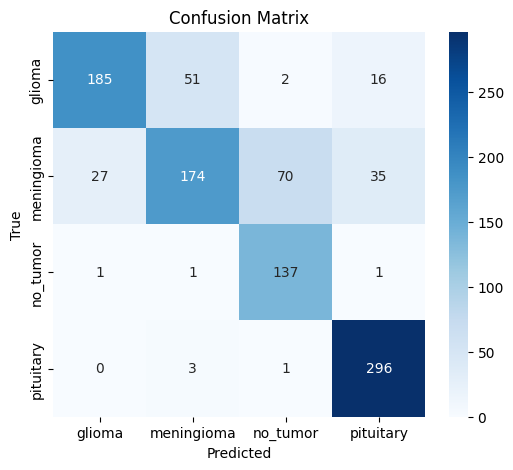

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()